<a href="https://colab.research.google.com/github/maureen-zhang/Pyrolitics/blob/main/pyrolitics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spring 2025 Erdos Institute Data Science Project - Pyrolitics

## Introduction

This notebook contains all the code for our Spring 2025 Erdos Institute Data Science project - Pyrolitics. The notebook is divided into three main parts:

1.  **Data Science:** Data cleaning, processing, and feature engineering to create a panel dataset.
2.  **Statistical Modeling:** Building and evaluating statistical models to analyze the relationships between variables.
3.  **Data Visualization:** Creating visualizations to explore and communicate the insights derived from the data.

## Data Sources

The project utilizes data from the following sources:

*   Wildfire data from [Kaggle](https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires/data)
*   Transmission line data from the [CA  Energy Comission](https://cecgis-caenergy.opendata.arcgis.com/datasets/CAEnergy::california-electric-transmission-lines-1/about)
*   Weather data from [NOAA' National Centers for Environmental Information.](https://www.ncei.noaa.gov/)

*   Electricity consumption data from [California Electricity Consumption Database
](https://catalog.data.gov/dataset/california-electricity-consumption-database-e26e9)

*   Vegetation data from the [California Department of Fish and Wildlife.](https://wildlife.ca.gov/Data/GIS/Vegetation-Data)


*Through cleaning and processing, we have obtained a panel dataset containing strategically engineered features ranging from year 1992 to year 2020.

*  County data was obtained from [data.gov.](https://catalog.data.gov/dataset/counties2)


#Data Science

## Data Mounting and Library Importing
- Import necessary libraries
- Mount Google Drive to access data files
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from shapely.geometry import Point
import re
import os
import geopandas as gpd
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from google.colab import drive
import sqlite3
import time
from shapely.ops import unary_union
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors

In [ ]:
drive.mount('/content/drive')
sns.set_style("whitegrid")
%matplotlib inline

Mounted at /content/drive


In [ ]:
# un-comment the line below to load a smaller wildfire dataset (which includes damage levels)
# df_wildfire = pd.read_csv("/content/drive/MyDrive/pyrolitics-shared-drive/CA_Wildfire_Kaggle.csv", low_memory=False)
# this has 10GB+ data which will take about 2 minutes to load
# ref: https://www.kaggle.com/datasets/behroozsohrabi/us-wildfire-records-6th-edition
if not os.path.exists("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/wildfire_ca.csv"):
    wildfire_large = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/data.csv")
    # select only california wildfire and save it as shp file
    wildfire_ca = wildfire_large[wildfire_large["STATE"]=="CA"]
    wildfire_ca.to_csv("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/wildfire_ca.csv", index=False)
else:
    wildfire_ca = pd.read_csv("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/wildfire_ca.csv")
    wildfire_ca = gpd.GeoDataFrame(wildfire_ca)
# county data
counties = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/ca_counties/CA_Counties.shp")
# transmission data
transmission_gdf = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/Transmission_Line_7304850911266214096/TransmissionLine_CEC.shp")
# vegeration data
vegetation_df = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/ds1020/ds1020.gdb/",layer=0)
# electricity consumption
electricity_consumption_df = pd.read_csv("/content/drive/MyDrive/pyrolitics-shared-drive/agg_electricity_consumption_county.csv")
# load vegetation
vegetations = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/ds1020/ds1020.gdb/",layer=0)

<ipython-input-3-6bc245038f34>:11: DtypeWarning: Columns (12,13,36) have mixed types. Specify dtype option on import or set low_memory=False.
  wildfire_ca = pd.read_csv("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/wildfire_ca.csv")


In [ ]:
print(wildfire_ca['FIRE_SIZE_CLASS'].unique())
wildfire_ca_ = wildfire_ca[['FIRE_NAME',
       'ICS_209_PLUS_INCIDENT_JOIN_ID', 'ICS_209_PLUS_COMPLEX_JOIN_ID',
       'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR',
       'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'NWCG_CAUSE_CLASSIFICATION', 'NWCG_GENERAL_CAUSE',
       'NWCG_CAUSE_AGE_CATEGORY', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME',
       'FIRE_SIZE', 'FIRE_SIZE_CLASS']]
print(wildfire_ca_['NWCG_GENERAL_CAUSE'].unique())

wildfire_ca_['Powerline_Related'] = wildfire_ca_['NWCG_GENERAL_CAUSE'].apply(lambda x: 1 if x == 'Power generation/transmission/distribution' else 0)

['A' 'B' 'G' 'C' 'F' 'D' 'E']
['Power generation/transmission/distribution' 'Natural'
 'Debris and open burning' 'Missing data/not specified/undetermined'
 'Recreation and ceremony' 'Equipment and vehicle use' 'Other causes'
 'Fireworks' 'Arson/incendiarism' 'Smoking' 'Misuse of fire by a minor'
 'Firearms and explosives use' 'Railroad operations and maintenance']


<ipython-input-4-fc175db1e742>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wildfire_ca_['Powerline_Related'] = wildfire_ca_['NWCG_GENERAL_CAUSE'].apply(lambda x: 1 if x == 'Power generation/transmission/distribution' else 0)


In [ ]:
wildfire_ca_['Powerline_Related'].value_counts()

,count
Powerline_Related,
0,248204
1,3677


In [ ]:
wildfire_ca_ = wildfire_ca.copy()

In [ ]:
# load weather data
def create_weather_panel_df( directory, file_names):
    """Returns the monthly maximum temperature and precipation for each county between 2013 and 2024"""
    data_frames = []
    for filename in file_names:

        file_path = os.path.join(directory, filename)
        df_tmp = pd.read_csv(file_path)

        df_tmp['Time'] = pd.to_datetime(df_tmp[['Year', 'Month']].assign(DAY=1))
        df_tmp['Time'] = df_tmp['Time'].dt.strftime('%m-%Y')

        df_tmp['Time'] = pd.to_datetime(df_tmp['Time'], format='%m-%Y')
        # df_tmp = df_tmp[(df_tmp['Time'] >= '2013-08-01') & (df_tmp['Time'] <= '2024-12-01')]
        df_tmp['Time'] = df_tmp['Time'].dt.strftime('%Y')

        df_tmp = df_tmp.drop(columns=['Year', 'Month'])

        data_frames.append(df_tmp.copy())

    # Concatenate all data frames
    df_local = pd.concat(data_frames, ignore_index=True)

    df_local.dropna(inplace=True)
    df_local.drop_duplicates(inplace=True)
    df_local = df_local.groupby(["County","Time"]).agg({"Maximum Temperature (°F)":"mean", "Average Temperature (°F)":"mean", "Precipitation (Inches)":"sum"})
    # df_local.set_index(['County', 'Time'], inplace=True)
    # df_local.index = df_local.index.reorder_levels(['County', 'Time']) # Force it to use the correct orde
    return df_local
# use Weather_Data_Extended for original data (contains only max temperature and precipitation)
directory = "/content/drive/MyDrive/pyrolitics-shared-drive/Weather_Data_California_Extended"
file_names = [f for f in os.listdir(directory) if f.endswith(".csv")]
df_weather = create_weather_panel_df(directory, file_names)

df_weather = df_weather.reset_index()
df_weather.Time = df_weather.Time.astype(int)
df_weather["Average Temperature (°F)"] = df_weather["Average Temperature (°F)"].apply(lambda x: (x - 32) * 5 / 9 + 273.15)
df_weather["Maximum Temperature (°F)"] = df_weather["Maximum Temperature (°F)"].apply(lambda x: (x - 32) * 5 / 9 + 273.15)

df_weather.drop(["Time"],axis=1)

In [ ]:
df_weather = df_weather.reset_index()
df_weather.Time = df_weather.Time.astype(int)
df_weather["Average Temperature (°F)"] = df_weather["Average Temperature (°F)"]
df_weather["Maximum Temperature (°F)"] = df_weather["Maximum Temperature (°F)"]
print(df_weather.columns)
df_weather = df_weather[(df_weather['Time']>=1992) & (df_weather['Time']<=2020)]
df_weather.shape

Index(['County', 'Time', 'Maximum Temperature (°F)',
       'Average Temperature (°F)', 'Precipitation (Inches)'],
      dtype='object')


(1682, 5)

In [ ]:
panel = df_weather.copy()
panel

,County,Time,Maximum Temperature (°F),Average Temperature (°F),Precipitation (Inches)
97,Alameda,1992,66.050000,60.191667,139.24
98,Alameda,1993,64.483333,58.983333,211.82
99,Alameda,1994,65.050000,57.725000,107.96
100,Alameda,1995,64.541667,59.900000,230.50
101,Alameda,1996,66.875000,60.366667,203.52
...,...,...,...,...,...
7588,Yuba,2016,69.291667,61.741667,338.90
7589,Yuba,2017,67.283333,62.283333,519.47
7590,Yuba,2018,69.408333,61.983333,260.66
7591,Yuba,2019,66.633333,60.883333,452.99


## Creating Wildfire Panel Dataframe

This section computes the distance between wild fires and transmmion lines, using GeoPanda.



In [ ]:
# ca wildfire processing
# to-do dropna lat lon
# format crs of counties file
counties_crs_4326 = counties.to_crs(epsg=4326)
# select useful features of fires and select rows that are in california
wildfire_df = wildfire_ca[["DISCOVERY_DATE","STATE","FIRE_SIZE","LATITUDE","LONGITUDE"]][wildfire_ca["STATE"]=="CA"]
# group selected columns by county and time
wildfire_df.rename(columns={"DISCOVERY_DATE":"Time"},inplace=True)
# create county and time as indices and then convert to year
wildfire_df['Time'] = pd.to_datetime(wildfire_df['Time'], format='%m/%d/%Y').dt.strftime('%Y')
# create Point objects for lat lon
wildfire_df['geometry'] = [Point(x,y) for x, y in zip(wildfire_df['LONGITUDE'], wildfire_df['LATITUDE'])]
# convert to geo-data-frame
wildfire_df = gpd.GeoDataFrame(wildfire_df,geometry="geometry",crs='EPSG:4326')
# spatial join counties info with large wildfire dataset
wildfire_df = gpd.sjoin(wildfire_df, counties_crs_4326[['geometry','NAME']], how="left", predicate='within')
wildfire_df.rename(columns={"NAME":"County"},inplace=True)
wildfire_df['Powerline_Related'] = wildfire_ca['NWCG_GENERAL_CAUSE'].apply(lambda x: 1 if x == 'Power generation/transmission/distribution' else 0)
# aggregage group by County and Time
# to-do: alternatively, can count total number of incidences in each state and year
wildfire_df["FIRE_SIZE"] = wildfire_df["FIRE_SIZE"].astype(float)
# group by county and time and aggregate by averging the fire size column
wildfire_df = wildfire_df.groupby(["County","Time"]).agg({"FIRE_SIZE":["mean","count"], "Powerline_Related": "sum"})
# reset index
wildfire_df = wildfire_df.reset_index()
# convert Time from strings to ints
wildfire_df.Time = wildfire_df.Time.astype(int)
wildfire_df.columns = [col_level1 + col_level2 for (col_level1, col_level2) in wildfire_df.columns]

```
un-comment to plot wild fire data
ca_wildfire_large.sort_values(by=["County","Time"],inplace=True)
# visualize firesize by County and Time
yticklabels = ca_wildfire_large.index.get_level_values("County")
xticklabels = ca_wildfire_large.index.get_level_values("Time")
pivot_df = ca_wildfire_large.pivot_table(index='County', columns='Time', aggfunc='first')

# plot fire size for every county in california
dict_counties = {}
times = []
values = []
for index_ in ca_wildfire_large.index:
    county = index_[0]
    year = int(index_[1])
    if county not in dict_counties:
        dict_counties[county] = [[],[]]
    dict_counties[county][0].append(year)
    dict_counties[county][1].append(ca_wildfire_large.loc[index_,"FIRE_SIZE"].values[0])
# Create a figure
fig, ax = plt.subplots(1, 1)  # 1 row, 1 columns of subplots
# Loop over the ys and xs to plot each
# for i, ax in enumerate():
for county, times_values in dict_counties.items():
    ax.plot(times_values[0], times_values[1], label=county)
ax.set_title(f"Total Fire Size Over Years For Every County in California")
ax.set_xlabel("Years")
ax.set_ylabel(f"Total Fire Size")
# Show the plot
plt.tight_layout()
plt.show()
```

In [ ]:
panel = pd.merge(panel,wildfire_df,on=("County","Time"),how='outer')
panel.fillna(0, inplace=True)

In [ ]:
panel

,County,Time,Maximum Temperature (°F),Average Temperature (°F),Precipitation (Inches),FIRE_SIZEmean,FIRE_SIZEcount,Powerline_Relatedsum
0,Alameda,1992,66.050000,60.191667,139.24,17.017742,62.0,0.0
1,Alameda,1993,64.483333,58.983333,211.82,19.747368,76.0,0.0
2,Alameda,1994,65.050000,57.725000,107.96,6.262000,50.0,0.0
3,Alameda,1995,64.541667,59.900000,230.50,23.751111,45.0,0.0
4,Alameda,1996,66.875000,60.366667,203.52,36.579661,59.0,0.0
...,...,...,...,...,...,...,...,...
1677,Yuba,2016,69.291667,61.741667,338.90,8.848116,69.0,0.0
1678,Yuba,2017,67.283333,62.283333,519.47,127.244247,73.0,0.0
1679,Yuba,2018,69.408333,61.983333,260.66,3.654416,77.0,0.0
1680,Yuba,2019,66.633333,60.883333,452.99,1.376410,39.0,0.0


## Merging With Transmission Lines

In [ ]:
types = ['OH']
transmission_gdf = transmission_gdf[transmission_gdf['Type'].isin(types)]

types_none = [None]
cleaned_transmission_gdf = transmission_gdf[~transmission_gdf['Name'].isin(types_none)]

#Match Lines with Counties
cleaned_transmission_gdf = cleaned_transmission_gdf.to_crs(counties.crs)
lines_with_counties = gpd.sjoin(cleaned_transmission_gdf, counties, how="left", predicate="intersects")

lines_with_counties = lines_with_counties[['NAME','Length_Mil']]
lines_with_counties = lines_with_counties.groupby(by='NAME').agg({'Length_Mil':'sum'})

In [ ]:
# calculate closest distances (takes 30 minutes to run)
file_path = '/content/drive/MyDrive/pyrolitics-shared-drive/transmission_lines_panel.csv'
# if not os.path.exists(file_path):
if not os.path.exists(file_path):
    wildfire_ca_copy = wildfire_ca.copy()
    # create Point objects for lat lon
    wildfire_ca_copy['geometry'] = [Point(x,y) for x, y in zip(wildfire_ca_copy['LONGITUDE'], wildfire_ca_copy['LATITUDE'])]
    # convert to geo-data-frame
    wildfire_ca_copy = gpd.GeoDataFrame(wildfire_ca_copy,geometry="geometry",crs='EPSG:4326')
    wildfire_ca_copy = wildfire_ca_copy[wildfire_ca["FIRE_YEAR"] > 1990]

    types = ['OH']
    transmission_gdf = transmission_gdf[transmission_gdf['Type'].isin(types)]
    types_none = [None]
    cleaned_transmission_gdf = transmission_gdf[~transmission_gdf['Name'].isin(types_none)]
    cleaned_transmission_gdf = cleaned_transmission_gdf.to_crs(wildfire_ca_copy.crs)

    # un-comment to use old code which is slow
    transmission_union = cleaned_transmission_gdf.union_all()
    wildfire_ca_copy['Closest_Distance'] = wildfire_ca_copy.geometry.apply(lambda point: point.distance(transmission_union))

    transmission_lines_panel = gpd.sjoin(wildfire_ca_copy, counties_crs_4326[['geometry','NAME']], how="left", predicate='within').rename(columns={"NAME":"County"})
    transmission_lines_panel = transmission_lines_panel[["County","DISCOVERY_DATE",'Closest_Distance']]
    transmission_lines_panel.to_csv(file_path, index=False)

    # group selected columns by county and time
    transmission_lines_panel.rename(columns={"DISCOVERY_DATE":"Time"},inplace=True)
    # create county and time as indices and then convert to year
    transmission_lines_panel['Time'] = pd.to_datetime(transmission_lines_panel['Time'], format='%m/%d/%Y').dt.strftime('%Y')

    transmission_lines_panel = transmission_lines_panel.groupby(['County','Time']).agg({"Closest_Distance": ['mean']})
    transmission_lines_panel = transmission_lines_panel.reset_index()
    # transmission_lines_panel.columns = ['_'.join(col).strip() if col[1] else col[0] for col in transmission_lines_panel.columns.values]
    transmission_lines_panel.to_csv(file_path, index=False, header=True)
else:
    transmission_lines_panel = pd.read_csv(file_path, header=[0, 1])
    print("transmission_lines_panel already existed in drive")

transmission_lines_panel already existed in drive


In [ ]:
transmission_lines_panel.columns = [col_level1 for (col_level1, col_level2) in transmission_lines_panel.columns]

In [ ]:
transmission_lines_panel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1677 entries, 0 to 1676
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   County            1677 non-null   object 
 1   Time              1677 non-null   int64  
 2   Closest_Distance  1677 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 39.4+ KB


In [ ]:
panel = pd.merge(panel,transmission_lines_panel,on=("County","Time"),how='outer')
panel.fillna(0, inplace=True)

In [ ]:
def add_length_mil_temp_dist(df__,counties,lines_with_counties):
    #Adding total number of OH Transmission lines (in miles to panel data as a constant)
    dummy = pd.DataFrame()

    # Time range from 1992 to 2020 as the wildfire data
    time_range = range(1992, 2021)

    multi_index = pd.MultiIndex.from_product([counties['NAME'], time_range], names=['County', 'Time'])

    # Assign the MultiIndex to the tiled DataFrame
    dummy.index = multi_index

    dummy['Length_Mil'] = 0
    for county in counties['NAME']:
        for year in time_range:
            dummy.loc[(county, year), 'Length_Mil'] = lines_with_counties.loc[county].values[0]

    df__ = df__.reset_index()
    dummy_ = dummy.reset_index()
    df__ = pd.merge(df__,dummy,on=("County","Time"),how='inner')
    print(df__.columns)
    df__ = df__.set_index(['County', 'Time'])
    df__['Length_Dist'] = df__['Length_Mil'] * df__['Closest_Distance']
    df__['Length_Temp'] = df__['Length_Mil'] * df__['Average Temperature (°F)']

    return df__.reset_index()
panel = add_length_mil_temp_dist(panel,counties,lines_with_counties)

Index(['index', 'County', 'Time', 'Maximum Temperature (°F)',
       'Average Temperature (°F)', 'Precipitation (Inches)', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Closest_Distance',
       'Length_Mil'],
      dtype='object')


In [ ]:
panel

,County,Time,index,Maximum Temperature (°F),Average Temperature (°F),Precipitation (Inches),FIRE_SIZEmean,FIRE_SIZEcount,Powerline_Relatedsum,Closest_Distance,Length_Mil,Length_Dist,Length_Temp
0,Alameda,1992,0,66.050000,60.191667,139.24,17.017742,62.0,0.0,0.012213,1355,16.548584,81559.708333
1,Alameda,1993,1,64.483333,58.983333,211.82,19.747368,76.0,0.0,0.011856,1355,16.065527,79922.416667
2,Alameda,1994,2,65.050000,57.725000,107.96,6.262000,50.0,0.0,0.011407,1355,15.456434,78217.375000
3,Alameda,1995,3,64.541667,59.900000,230.50,23.751111,45.0,0.0,0.012394,1355,16.794354,81164.500000
4,Alameda,1996,4,66.875000,60.366667,203.52,36.579661,59.0,0.0,0.012588,1355,17.056344,81796.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,Yuba,2016,1677,69.291667,61.741667,338.90,8.848116,69.0,0.0,0.024527,537,13.170732,33155.275000
1678,Yuba,2017,1678,67.283333,62.283333,519.47,127.244247,73.0,0.0,0.023737,537,12.746666,33446.150000
1679,Yuba,2018,1679,69.408333,61.983333,260.66,3.654416,77.0,0.0,0.026615,537,14.292202,33285.050000
1680,Yuba,2019,1680,66.633333,60.883333,452.99,1.376410,39.0,0.0,0.017019,537,9.139154,32694.350000


## Merging Weather Data

## Merging Electricity Consumption

In [ ]:
electricity_consumption_df.head()

,Year,CountyNum,CountyName,Sector,RNR,GWh
0,1990,1,ALAMEDA,Agriculture and Water Pumping,NR,903.919433
1,1990,1,ALAMEDA,Commercial,NR,3477.775257
2,1990,1,ALAMEDA,Industrial,NR,1895.868822
3,1990,1,ALAMEDA,Mining,NR,107.551622
4,1990,1,ALAMEDA,Residential,R,2498.265626


In [ ]:
# process consumption data. May need to change 'df_total' and 'df_local' to other names
electricity_consumption_df = electricity_consumption_df.rename(columns={"Year":"Time"}).rename(columns={"CountyName":"County"})
electricity_consumption_df = electricity_consumption_df.groupby(['County','Time'])['GWh'].sum().reset_index() #aggregate all sectors
electricity_consumption_df['County'] = electricity_consumption_df['County'].str.title() # Chance ALAMEDA to Alameda, etc.
# electricity_consumption_df = electricity_consumption_df.set_index(['County', 'Time'])
electricity_consumption_df = electricity_consumption_df.groupby(['County','Time']).agg({"GWh":"sum"}) # to match levels of merged data-frame
# reset index and drop index as column
electricity_consumption_df = electricity_consumption_df.reset_index()
# convert years from ints to strings
electricity_consumption_df["Time"] = electricity_consumption_df["Time"].astype(int)

In [ ]:
electricity_consumption_df.head()

,County,Time,GWh
0,Alameda,1990,9607.565521
1,Alameda,1991,9324.783738
2,Alameda,1992,9287.523316
3,Alameda,1993,9790.005719
4,Alameda,1994,9442.803438


```
un-comment to convert processed electricity consumption to a dictionary
dict_electricity_consumption = {}
for index, row in electricity_consumption_df.iterrows():
    dict_electricity_consumption[index] = float(row)

new_df['GWh'] = 0
for index, _ in new_df.iterrows():
    county, time = index
    if (county, int(time)) in dict_electricity_consumption:
        print((county, int(time)))
        new_df.loc[index,'GWh'] = dict_electricity_consumption[(county, int(time))]
new_df['GWh']
```

In [ ]:
panel = pd.merge(panel,electricity_consumption_df,on=["County","Time"],how='inner')
panel.fillna(0, inplace=True)

In [ ]:
panel

,County,Time,index,Maximum Temperature (°F),Average Temperature (°F),Precipitation (Inches),FIRE_SIZEmean,FIRE_SIZEcount,Powerline_Relatedsum,Closest_Distance,Length_Mil,Length_Dist,Length_Temp,GWh
0,Alameda,1992,0,66.050000,60.191667,139.24,17.017742,62.0,0.0,0.012213,1355,16.548584,81559.708333,9287.523316
1,Alameda,1993,1,64.483333,58.983333,211.82,19.747368,76.0,0.0,0.011856,1355,16.065527,79922.416667,9790.005719
2,Alameda,1994,2,65.050000,57.725000,107.96,6.262000,50.0,0.0,0.011407,1355,15.456434,78217.375000,9442.803438
3,Alameda,1995,3,64.541667,59.900000,230.50,23.751111,45.0,0.0,0.012394,1355,16.794354,81164.500000,9858.388896
4,Alameda,1996,4,66.875000,60.366667,203.52,36.579661,59.0,0.0,0.012588,1355,17.056344,81796.833333,10384.333836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,Yuba,2016,1677,69.291667,61.741667,338.90,8.848116,69.0,0.0,0.024527,537,13.170732,33155.275000,481.144062
1678,Yuba,2017,1678,67.283333,62.283333,519.47,127.244247,73.0,0.0,0.023737,537,12.746666,33446.150000,504.212722
1679,Yuba,2018,1679,69.408333,61.983333,260.66,3.654416,77.0,0.0,0.026615,537,14.292202,33285.050000,502.749287
1680,Yuba,2019,1680,66.633333,60.883333,452.99,1.376410,39.0,0.0,0.017019,537,9.139154,32694.350000,509.943569


## Merging With Vegetation

In [ ]:
# process counties
counties_crs_for_veg = counties.copy()
counties_crs_for_veg = counties_crs_for_veg[["AWATER","ALAND","Shape_Area","geometry","NAME"]]
counties_crs_for_veg["water_percentage"] = counties_crs_for_veg["AWATER"] / counties_crs_for_veg["Shape_Area"]
counties_crs_for_veg.sort_values("water_percentage",ascending=False)
counties_crs_for_veg = counties_crs_for_veg[["geometry","water_percentage","NAME"]]
counties_crs_for_veg = counties_crs_for_veg.rename(columns={"NAME":"County"})
counties_crs_for_veg = counties_crs_for_veg.to_crs("EPSG:3395")
counties_crs_for_veg = counties_crs_for_veg.set_geometry('geometry')
counties_crs_for_veg.head(5)

,geometry,water_percentage,County
0,"POLYGON ((-13431319.751 4794216.354, -13431312...",0.005547,Sierra
1,"POLYGON ((-13490651.476 4654103.527, -13490511...",0.017935,Sacramento
2,"MULTIPOLYGON (((-13440081.316 4125946.413, -13...",0.188279,Santa Barbara
3,"POLYGON ((-13428575.483 4601215.292, -13428534...",0.010064,Calaveras
4,"MULTIPOLYGON (((-13283668.94 4035403.146, -132...",0.112601,Ventura


In [ ]:
# process vegetation
def f(datetime_string):
    year, month = re.split(r'[/\s]+',datetime_string)[:2]
    return f"{month}-{year}"
#vegetations_to_merge['Time'] = vegetations_to_merge['SurveyDate'].astype(str).apply(f)
vegetations_to_merge = vegetations.copy()
vegetations_to_merge = vegetations_to_merge.to_crs("EPSG:3395")

treecov_mapping = {
    None: 0,
    '< 1 acre': 0,  # or 1, depending on how you want to treat '< 1 acre'
    '1-5 acres': 3,  # Average of 1 and 5
    '> 5 acres': 6,  # or a larger value if '> 5 acres' represents much higher coverage
    'Not recorded': 0,  # or a value representing missing data
    'Extensive': 10,  # Assuming 'Extensive' means very high coverage
    'Large': 8,
    'Small': 2,
    '<1 acre': 0,
    '>5 acres': 6,
    'Very Small': 1,
    'Unknown': 0,  # or a value representing missing data
    ' ': 0,
    ' 20': 20,
    ' 25': 25,
    '< 1 acres': 0,
    '1 - 5 acres': 3,
    ' < 1 acre': 0,
    ' > 5 acres': 6,
    ' 1-5 acres': 3,
    'Not Recorded': 0,
    '1to5Acres': 3,
    'not recorded': 0,
    '<Null>': 0
}
# handle nan and apply mapping
vegetations_to_merge['Stand_Size'] = vegetations_to_merge['Stand_Size'].map(treecov_mapping).fillna(0)

# handle acres
vegetations_to_merge['Stand_Size'] = vegetations_to_merge['Stand_Size'].apply(lambda x: x * 4046.86 if isinstance(x, (int, float)) and x > 10 else x)
vegetations_to_merge = vegetations_to_merge[vegetations_to_merge['Stand_Size'] != 0]
vegetations_to_merge['TreeCov']=vegetations_to_merge['Stand_Size']*vegetations_to_merge['TreeCov']

vegetations_to_merge = vegetations_to_merge[['TreeCov','geometry']]
vegetations_to_merge.fillna(0,inplace=True)
vegetations_to_merge = gpd.sjoin(vegetations_to_merge, counties_crs_for_veg[['County','geometry']].to_crs("EPSG:3395"), how="left", predicate='within')
vegetations_to_merge.drop(columns=['index_right'],inplace=True)
vegetations_to_merge = vegetations_to_merge.groupby(['County']).agg({'TreeCov':'sum'})
vegetations_to_merge = vegetations_to_merge.reset_index()

all_counties = counties_crs_for_veg['County'].unique()
missing_counties = np.setdiff1d(all_counties, vegetations_to_merge['County'])
missing_df = pd.DataFrame({'County': missing_counties, 'TreeCov': 0})
vegetations_to_merge = pd.concat([vegetations_to_merge, missing_df], ignore_index=True)
vegetations_to_merge.set_index('County', inplace=True)

print(vegetations_to_merge.columns)

def add_tree_cov(df__):
  #Adding total number of OH Transmission lines (in miles to panel data as a constant)
  dummy = pd.DataFrame()

  # Time range from 1992 to 2020 as the wildfire data
  time_range = range(1992, 2021)

  multi_index = pd.MultiIndex.from_product([counties['NAME'], time_range], names=['County', 'Time'])

  # Assign the MultiIndex to the tiled DataFrame
  dummy.index = multi_index

  dummy['TreeCov'] = 0
  for county in counties['NAME']:
      for year in time_range:
        dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]

  df__ = df__.reset_index()
  dummy_ = dummy.reset_index()
  print(df__.head())
  df__ = pd.merge(df__,dummy,on=("County","Time"),how='inner')
  print(df__.head())
  df__['TreeCov_Resp'] = df__['TreeCov'] * df__['Precipitation']
  df__['TreeCov_Temp'] = df__['TreeCov'] * df__['AverageTemperature']
  df__['TreeCov_Time'] = df__['TreeCov'] * df__['Time']
  print(df__.head())
  df__ = df__.set_index(['County', 'Time'])
  return df__

Index(['TreeCov'], dtype='object')


In [ ]:
wildfire_ca.columns

Index(['OBJECTID', 'Shape', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE',
       'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_PLUS_INCIDENT_JOIN_ID', 'ICS_209_PLUS_COMPLEX_JOIN_ID',
       'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR',
       'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'NWCG_CAUSE_CLASSIFICATION', 'NWCG_GENERAL_CAUSE',
       'NWCG_CAUSE_AGE_CATEGORY', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME',
       'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_DESCR',
       'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME'],
      dtype='object')

In [ ]:
# create interacton variable time and vegetation
wildfire_ca_for_veg = wildfire_ca.copy()
wildfire_ca_for_veg = wildfire_ca_for_veg[["FIRE_SIZE","DISCOVERY_DATE",'LONGITUDE','LATITUDE','DISCOVERY_TIME','DISCOVERY_DOY']]
wildfire_ca_for_veg.dropna(subset=['LONGITUDE','LATITUDE'])
wildfire_ca_for_veg["geometry"] = [Point(x,y) for x, y in zip(wildfire_ca_for_veg['LONGITUDE'], wildfire_ca_for_veg['LATITUDE'])]
# Set the 'geometry' column as the active geometry column
wildfire_ca_for_veg = wildfire_ca_for_veg.set_geometry('geometry')
wildfire_ca_for_veg = wildfire_ca_for_veg.set_crs("EPSG:4326", allow_override=True)
wildfire_ca_for_veg = wildfire_ca_for_veg.to_crs("EPSG:3395")
# rename
wildfire_ca_for_veg = wildfire_ca_for_veg.rename(columns={"DISCOVERY_DATE":"Time","NAME":"County"})
# create county and time as indices and then convert to year
wildfire_ca_for_veg['Time'] = pd.to_datetime(wildfire_ca_for_veg['Time'], format='%m/%d/%Y').dt.year
# group by county and time and aggregate by averging the fire size column
wildfire_ca_for_veg = gpd.sjoin(wildfire_ca_for_veg, counties_crs_for_veg, how="left", predicate='within')
# add time and day of year to get month-hour as time variable
wildfire_ca_for_veg["time_variation"] = np.sin(2 * np.pi * wildfire_ca_for_veg['DISCOVERY_DOY'] / 365) + np.sin(2 * np.pi * wildfire_ca_for_veg['DISCOVERY_TIME'] / 2400)
wildfire_ca_for_veg = wildfire_ca_for_veg.groupby(["County","Time"]).agg({"time_variation":"mean"})
# replace null values with 0
wildfire_ca_for_veg["time_variation"] = wildfire_ca_for_veg["time_variation"].fillna(0)
wildfire_ca_for_veg = wildfire_ca_for_veg.reset_index()
wildfire_ca_for_veg.head(20)

,County,Time,time_variation
0,Alameda,1992,-0.361950
1,Alameda,1993,0.000000
2,Alameda,1994,0.000000
3,Alameda,1995,0.000000
4,Alameda,1996,0.000000
5,Alameda,1997,0.000000
6,Alameda,1998,-1.210258
7,Alameda,1999,-1.217080
8,Alameda,2000,-0.506827
9,Alameda,2001,-0.762285


In [ ]:
# interpolate missing years for each county
vegetations_to_agg = vegetations.copy()
vegetations_to_agg = vegetations_to_agg.to_crs("EPSG:3395")
def f(datetime_string):
    year, month = re.split(r'[/\s]+',datetime_string)[:2]
    return f"{month}-{year}"
vegetations_to_agg['Time'] = vegetations_to_agg['SurveyDate'].astype(str).apply(f)
# merge counties into vegetations
vegetations_to_agg = vegetations_to_agg[["Time","geometry","TotalVegCov"]].dropna(subset=["TotalVegCov"]) # other useful columns are "HdwdCov","ConCov","TreeCov","MCVGroup"
vegetations_to_agg['Time'] = pd.to_datetime(vegetations_to_agg['Time'],format='%m-%Y')
vegetations_to_agg['Time'] = vegetations_to_agg['Time'].dt.year.astype(int)
# vegetations_to_merge = vegetations_to_merge[vegetations_to_merge['Time'].notna()]
# create lat lon
vegetations_to_agg["LONGITUDE"] = vegetations_to_agg.geometry.apply(lambda g: g.x)
vegetations_to_agg["LATITUDE"] = vegetations_to_agg.geometry.apply(lambda g: g.y)
# spatial join using county boundaries
vegetations_to_agg = gpd.sjoin(vegetations_to_agg, counties_crs_for_veg, how="left", predicate='within')
vegetations_to_agg = vegetations_to_agg.groupby(["County","Time"]).agg({"TotalVegCov":"sum","water_percentage":"mean"})
vegetations_to_agg = vegetations_to_agg.reset_index()
def interpolate_treecov_years_per_county(df,treecov="TotalVegCov",entity="County",time="Time"):
    # Ensure correct data types
    df[time] = df[time].astype(int)
    df.sort_values(by=[entity, time], inplace=True)
    # Interpolate missing vegetation values
    df[treecov] = df.groupby(entity)[treecov].transform(lambda group: group.interpolate())
    # Fill remaining NaNs at the beginning or end (if needed)
    df[treecov] = df.groupby(entity)[treecov].transform(lambda group: group.fillna(method='bfill').fillna(method='ffill'))
    return df
vegetations_to_agg = interpolate_treecov_years_per_county(vegetations_to_agg)
vegetations_to_agg.head()

<ipython-input-29-de80ef4e34ec>:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[treecov] = df.groupby(entity)[treecov].transform(lambda group: group.fillna(method='bfill').fillna(method='ffill'))


,County,Time,TotalVegCov,water_percentage
0,Alameda,2003,205.0,0.063831
1,Alameda,2021,279.0,0.063831
2,Amador,2005,599.0,0.011501
3,Amador,2006,2626.0,0.011501
4,Amador,2008,3461.0,0.011501


In [ ]:
# create interaction variable btw time variation and vegetation coverage
vegetations_wildfire_interaction = pd.merge(vegetations_to_agg,wildfire_ca_for_veg,on=["County","Time"],how='inner')
vegetations_wildfire_interaction["veg_time_interaction"] = vegetations_wildfire_interaction["time_variation"] * vegetations_wildfire_interaction["TotalVegCov"]
vegetations_wildfire_interaction = vegetations_wildfire_interaction[["County","Time","veg_time_interaction"]]
vegetations_wildfire_interaction

,County,Time,veg_time_interaction
0,Alameda,2003,-125.999843
1,Amador,2005,-421.897655
2,Amador,2006,-1333.189883
3,Amador,2008,264.074862
4,Butte,2001,-111.775011
...,...,...,...
393,Yuba,2005,-3009.186197
394,Yuba,2006,-106.322652
395,Yuba,2010,-125.155261
396,Yuba,2011,-807.826218


In [ ]:
panel = pd.merge(panel,vegetations_wildfire_interaction,on=["County","Time"],how='inner')

In [ ]:
print(panel.info())
panel.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   County                    398 non-null    object 
 1   Time                      398 non-null    int64  
 2   index                     398 non-null    int64  
 3   Maximum Temperature (°F)  398 non-null    float64
 4   Average Temperature (°F)  398 non-null    float64
 5   Precipitation (Inches)    398 non-null    float64
 6   FIRE_SIZEmean             398 non-null    float64
 7   FIRE_SIZEcount            398 non-null    float64
 8   Powerline_Relatedsum      398 non-null    float64
 9   Closest_Distance          398 non-null    float64
 10  Length_Mil                398 non-null    int64  
 11  Length_Dist               398 non-null    float64
 12  Length_Temp               398 non-null    float64
 13  GWh                       398 non-null    float64
 14  veg_time_i

,County,Time,index,Maximum Temperature (°F),Average Temperature (°F),Precipitation (Inches),FIRE_SIZEmean,FIRE_SIZEcount,Powerline_Relatedsum,Closest_Distance,Length_Mil,Length_Dist,Length_Temp,GWh,veg_time_interaction
0,Alameda,2003,11,66.300000,59.666667,95.33,13.895652,46.0,0.0,0.015620,1355,21.165058,80848.333333,10588.916325,-125.999843
1,Amador,2005,71,64.108333,57.966667,337.93,1.919444,54.0,0.0,0.028224,187,5.277803,10839.766667,295.056820,-421.897655
2,Amador,2006,72,63.750000,57.700000,340.40,7.786567,67.0,5.0,0.034202,187,6.395858,10789.900000,307.616010,-1333.189883
3,Amador,2008,74,64.533333,58.391667,198.74,8.601724,58.0,3.0,0.029874,187,5.586522,10919.241667,331.794048,264.074862
4,Butte,2001,96,67.308333,60.416667,287.83,35.477603,317.0,7.0,0.025350,1102,27.935545,66579.166667,1248.119405,-111.775011


#Statistical Models

```
original code for PVAR
# Sample panel data (replace with your actual data)
# data = pd.DataFrame({
#     'County': [1, 1, 1, 2, 2, 2, 3, 3, 3],
#     'Time': [1, 2, 3, 1, 2, 3, 1, 2, 3],
#     'var1': [10, 12, 15, 20, 23, 25, 5, 7, 9],
#     'var2': [5, 6, 8, 12, 15, 17, 3, 4, 6]
# })
# Pivot the data to the correct format
# Reset index to work with columns
df = panel.reset_index().rename(columns={'level_0': 'Time', 'level_1': 'County'})

# Convert Month to datetime
# df['Time'] = pd.to_datetime(df['Time'], format='%m-%Y')

# Step 1: Reset and parse your date
# df = panel.reset_index().rename(columns={'level_0': 'Month', 'level_1': 'County'})
# df['Time'] = pd.to_datetime(df['Time'], format='%m-%Y')
# Step 2: Extract year only (2-digit or 4-digit, choose one)
# df['Year'] = df['Time'].dt.year
# Step 3: Group by Year and County, and average
# df_yearly = df.groupby(['Year', 'County']).mean(numeric_only=True).reset_index()

df_yearly.info()
# # Sort properly
df.sort_values(['County', 'Time'], inplace=True)
data_pivot = df.pivot(index='Time', columns='County', values=['Monthly_Consumption_(GWh)', 'Damage Percentage'])
data_pivot.columns = ['_'.join(col).strip() for col in data_pivot.columns.values]
# Fit the PVAR model
model = VAR(data_pivot)
# Select the order of the model
results = model.fit(2)
# Print the summary of the model
print(results.summary())
# Make predictions
lag_order = results.k_ar
predictions = results.forecast(data_pivot.values[-lag_order:], steps=5)
print(predictions)
```

### Linear Models

> First we install linear models.



In [ ]:
!pip3 install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.1 MB/s eta 0:00:00


This is what the code looks like to get the causal relationships.

In [ ]:
# no more data processing behind this point (df is fed directly regression)
df = panel.copy()
df = df.rename(columns={
    'Maximum Temperature (°F)': 'MaximumTemperature',
    'Average Temperature (°F)': 'AverageTemperature',
    'Precipitation (Inches)': 'Precipitation',
    'GWh':'Consumption'
})

df = add_tree_cov(df)
df['Consumption_vegetation'] = df['Consumption'] * df['veg_time_interaction']
df['Consumption_TreeCov'] = df['Consumption'] * df['TreeCov']
df['Consumption_Dist'] = df['Consumption'] * df['Closest_Distance']
df['Consumption_Length'] = df['Consumption'] * df['Length_Mil']

df.head()

<ipython-input-93-70a0e814f260>:73: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


   level_0   County  Time  index  MaximumTemperature  AverageTemperature  \
0        0  Alameda  2003     11         66.30000000         59.66666667   
1        1   Amador  2005     71         64.10833333         57.96666667   
2        2   Amador  2006     72         63.75000000         57.70000000   
3        3   Amador  2008     74         64.53333333         58.39166667   
4        4    Butte  2001     96         67.30833333         60.41666667   

   Precipitation  FIRE_SIZEmean  FIRE_SIZEcount  Powerline_Relatedsum  \
0    95.33000000    13.89565217     46.00000000            0.00000000   
1   337.93000000     1.91944444     54.00000000            0.00000000   
2   340.40000000     7.78656716     67.00000000            5.00000000   
3   198.74000000     8.60172414     58.00000000            3.00000000   
4   287.83000000    35.47760252    317.00000000            7.00000000   

   Closest_Distance  Length_Mil  Length_Dist    Length_Temp    Consumption  \
0        0.01561997       

level_0  index  MaximumTemperature  AverageTemperature  \
County  Time                                                           
Alameda 2003        0     11         66.30000000         59.66666667   
Amador  2005        1     71         64.10833333         57.96666667   
        2006        2     72         63.75000000         57.70000000   
        2008        3     74         64.53333333         58.39166667   
Butte   2001        4     96         67.30833333         60.41666667   

              Precipitation  FIRE_SIZEmean  FIRE_SIZEcount  \
County  Time                                                 
Alameda 2003    95.33000000    13.89565217     46.00000000   
Amador  2005   337.93000000     1.91944444     54.00000000   
        2006   340.40000000     7.78656716     67.00000000   
        2008   198.74000000     8.60172414     58.00000000   
Butte   2001   287.83000000    35.47760252    317.00000000   

              Powerline_Relatedsum  Closest_Distance  Length_Mil  ...  \
County  Time                                                      ...   
Alameda 2003            0.00000000        0.01561997        1355  ...   
Amador  2005            0.00000000        0.02822355         187  ...   
        2006            5.00000000        0.03420245         187  ...   
        2008            3.00000000        0.02987445         187  ...   
Butte   2001            7.00000000        0.02534986        1102  ...   

                Consumption  veg_time_interaction      TreeCov  \
County  Time                                                     
Alameda 2003 10588.91632483         -125.99984332   0.00000000   
Amador  2005   295.05681977         -421.89765458   0.00000000   
        2006   307.61601021        -1333.18988265   0.00000000   
        2008   331.79404785          264.07486196   0.00000000   
Butte   2001  1248.11940453         -111.77501087 793.80000003   

                TreeCov_Resp   TreeCov_Temp     TreeCov_Time  \
County  Time                                                   
Alameda 2003      0.00000000     0.00000000       0.00000000   
Amador  2005      0.00000000     0.00000000       0.00000000   
        2006      0.00000000     0.00000000       0.00000000   
        2008      0.00000000     0.00000000       0.00000000   
Butte   2001 228479.45400772 47958.75000162 1588393.80005367   

              Consumption_vegetation  Consumption_TreeCov  Consumption_Dist  \
County  Time                                                                  
Alameda 2003       -1334201.79785366           0.00000000      165.39854513   
Amador  2005        -124483.78022810           0.00000000        8.32754984   
        2006        -410110.55255315           0.00000000       10.52122116   
        2008          87618.46738553           0.00000000        9.91216455   
Butte   2001        -139508.56001195      990757.18334860       31.63965184   

              Consumption_Length  
County  Time                      
Alameda 2003   14347981.62014465  
Amador  2005      55175.62529662  
        2006      57524.19390908  
        2008      62045.48694832  
Butte   2001    1375427.58379096  

[5 rows x 22 columns]

In [ ]:
import pandas as pd
from linearmodels.panel import PanelOLS
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant

# Run the model WITHOUT setting the index
# Use the "entity_effects" and "time_effects" flags
# water_percentage + TotalVegCov + closest_distance_vegetation + AverageTemperature +
# to-do [april 5th Junhui]: play around with different combinations of features to find lowest p-value configurations
model = PanelOLS.from_formula(
    formula='FIRE_SIZEcount ~ Length_Temp + Consumption_Length+Length_Dist + Powerline_Relatedsum + Consumption+ Consumption_vegetation+MaximumTemperature + Precipitation+Consumption_TreeCov + EntityEffects + TimeEffects',
    #formula='GWh ~ AverageTemperature+Consumption_Dist+Length_Time +closest_distance_vegetation + Closest_Distance +FIRE_SIZE + MaximumTemperature + Precipitation + EntityEffects + TimeEffects',
    data=df,
    drop_absorbed=True,
)

results = model.fit(
    cov_type='clustered',
    cluster_entity=True,
    #entity_effects=True,
    #time_effects=True
)

print(results.summary)



                          PanelOLS Estimation Summary                           
Dep. Variable:         FIRE_SIZEcount   R-squared:                        0.3826
Estimator:                   PanelOLS   R-squared (Between):             -17.279
No. Observations:                 398   R-squared (Within):               0.1537
Date:                Sat, Apr 19 2025   R-squared (Overall):             -14.567
Time:                        17:57:30   Log-likelihood                   -2262.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      21.348
Entities:                          52   P-value                           0.0000
Avg Obs:                       7.6538   Distribution:                   F(9,310)
Min Obs:                       1.0000                                           
Max Obs:                       18.000   F-statistic (robust):             23.204
                            

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Assuming 'df' is your panel DataFrame with 'County' and 'Time' as index levels

# Reset index to access 'County' and 'Time' as columns
df_reset = df.reset_index()

# Features and target variable
features = ['Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum',
            'Consumption_vegetation', 'AverageTemperature', 'Consumption',
            'MaximumTemperature', 'Precipitation', 'TreeCov', 'Consumption_TreeCov']
target = 'FIRE_SIZEcount'

# Create GroupKFold for splitting by 'County'
group_kfold = GroupKFold(n_splits=5)  # Adjust n_splits as needed

# Store results
mse_scores = []
r2_scores = []

# Iterate through folds
for train_index, test_index in group_kfold.split(df_reset[features], df_reset[target], groups=df_reset['County']):
    X_train, X_test = df_reset.loc[train_index, features], df_reset.loc[test_index, features]
    y_train, y_test = df_reset.loc[train_index, target], df_reset.loc[test_index, target]

    # Create and train Random Forest model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = rf_model.predict(X_test)
    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

# Print average scores
print(f"Average Mean Squared Error: {sum(mse_scores) / len(mse_scores)}")
print(f"Average R-squared: {sum(r2_scores) / len(r2_scores)}")

Average Mean Squared Error: 34272.73719269621
Average R-squared: -0.37502088637508973


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score

# Assuming 'df' is your panel DataFrame with 'County' and 'Time' as index levels

# Reset index to access 'County' and 'Time' as columns
df_reset = df.reset_index()

# Features and target variable
features = ['Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum',
            'Consumption_vegetation', 'AverageTemperature', 'Consumption',
            'MaximumTemperature', 'Precipitation', 'TreeCov', 'Consumption_TreeCov']
target = 'FIRE_SIZEcount'

# Create GroupKFold for splitting by 'County'
group_kfold = GroupKFold(n_splits=5)  # Adjust n_splits as needed

# Store results
mse_scores = []
r2_scores = []

# Iterate through folds
for train_index, test_index in group_kfold.split(df_reset[features], df_reset[target], groups=df_reset['County']):
    X_train, X_test = df_reset.loc[train_index, features], df_reset.loc[test_index, features]
    y_train, y_test = df_reset.loc[train_index, target], df_reset.loc[test_index, target]

    # Create and train XGBoost model
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
    xgb_model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = xgb_model.predict(X_test)
    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

# Print average scores
print(f"Average Mean Squared Error: {sum(mse_scores) / len(mse_scores)}")
print(f"Average R-squared: {sum(r2_scores) / len(r2_scores)}")

Average Mean Squared Error: 30197.15257434096
Average R-squared: -0.34356658271802826


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Assuming 'df' is your panel DataFrame with 'County' and 'Time' as index levels

# Reset index to access 'County' and 'Time' as columns
df_reset = df.reset_index()

# Features and target variable
features = ['Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum',
            'Consumption_vegetation', 'AverageTemperature', 'Consumption',
            'MaximumTemperature', 'Precipitation', 'TreeCov']
target = 'FIRE_SIZEcount'

# Create GroupKFold for splitting by 'County'
group_kfold = GroupKFold(n_splits=5)  # Adjust n_splits as needed

# Store results
mse_scores = []
r2_scores = []

# Iterate through folds
for train_index, test_index in group_kfold.split(df_reset[features], df_reset[target], groups=df_reset['County']):
    X_train, X_test = df_reset.loc[train_index, features], df_reset.loc[test_index, features]
    y_train, y_test = df_reset.loc[train_index, target], df_reset.loc[test_index, target]

    # Create pipeline with StandardScaler and XGBoost
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
    ])

    # Train the pipeline
    pipeline.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = pipeline.predict(X_test)
    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

# Print average scores
print(f"Average Mean Squared Error: {sum(mse_scores) / len(mse_scores)}")
print(f"Average R-squared: {sum(r2_scores) / len(r2_scores)}")

Average Mean Squared Error: 25601.42638616363
Average R-squared: 0.10532108813564194


In [ ]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Assuming 'df' is your panel DataFrame with 'County' and 'Time' as index levels

# Reset index to access 'County' and 'Time' as columns
df_reset = df.reset_index()

# Features and target variable
features = ['Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum',
            'Consumption_vegetation', 'AverageTemperature', 'Consumption',
            'MaximumTemperature', 'Precipitation', 'TreeCov', 'Consumption_TreeCov',
            'Year', 'Time_Squared', 'Time_Cubed']
target = 'FIRE_SIZEcount'

# Create TimeSeriesSplit for splitting by time
tscv = TimeSeriesSplit(n_splits=5)  # Adjust n_splits as needed

# Store results
mse_scores = []
r2_scores = []

# Create preprocessor (scaling)
numeric_features = ['Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum',
                   'Consumption_vegetation', 'AverageTemperature', 'Consumption',
                   'MaximumTemperature', 'Precipitation', 'TreeCov', 'Consumption_TreeCov']
time_features = ['Time']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ],
    remainder='passthrough'
)

# Iterate through folds
for train_index, test_index in tscv.split(df_reset[features]):
    X_train, X_test = df_reset.loc[train_index, features], df_reset.loc[test_index, features]
    y_train, y_test = df_reset.loc[train_index, target], df_reset.loc[test_index, target]

    # Create pipeline with preprocessor and XGBoost
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
    ])

    # Train the pipeline
    pipeline.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = pipeline.predict(X_test)
    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

# Print average scores
print(f"Average Mean Squared Error: {sum(mse_scores) / len(mse_scores)}")
print(f"Average R-squared: {sum(r2_scores) / len(r2_scores)}")

KeyError: "['Year', 'Time_Squared', 'Time_Cubed'] not in index"

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Assuming 'df' is your panel DataFrame with 'County' and 'Time' as index levels

# Reset index to access 'County' and 'Time' as columns
df_reset = df.reset_index()

# Features and target variable
features = ['Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum',
            'Consumption_vegetation', 'AverageTemperature', 'Consumption',
            'MaximumTemperature', 'Precipitation', 'TreeCov', 'Consumption_TreeCov',
            'Year', 'Time_Squared', 'Time_Cubed']
target = 'FIRE_SIZEcount'

# Create preprocessor (scaling)
numeric_features = ['Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum',
                   'Consumption_vegetation', 'AverageTemperature', 'Consumption',
                   'MaximumTemperature', 'Precipitation', 'TreeCov', 'Consumption_TreeCov']
time_features = ['Year', 'Time_Squared', 'Time_Cubed']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('time', StandardScaler(), time_features)],
    remainder='passthrough'
)

# Sort the DataFrame by 'Time'
df_reset.sort_values(by=['Time'], inplace=True)

# Calculate the split index based on the desired percentage for training
split_index = int(len(df_reset) * 0.8)  # 80% for training

# Create train and test sets
X_train = df_reset.iloc[:split_index][features]
X_test = df_reset.iloc[split_index:][features]
y_train = df_reset.iloc[:split_index][target]
y_test = df_reset.iloc[split_index:][target]

# Create pipeline with preprocessor and XGBoost
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

# Train the pipeline
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

KeyError: "['Year', 'Time_Squared', 'Time_Cubed'] not in index"

In [ ]:
# # Get the exogenous variables (independent variables including the constant)
# exog_vars = model.exog

# residuals = results.resids.values

# exog_vars = add_constant(results.model.exog.values)

# # Perform the Breusch-Pagan test
# bp_test = het_breuschpagan(residuals, exog_vars)

# # get the p-value and check if less than 0.05 or not
# lm_statistic, lm_pvalue, f_statistic, f_pvalue = bp_test

# print(f"LM Statistic: {lm_statistic:.4f}")
# print(f"LM p-value: {lm_pvalue:.4f}")
# print(f"F Statistic: {f_statistic:.4f}")
# print(f"F p-value: {f_pvalue:.4f}")

Below, we show that our feature selection increases the predictability of number of wildfires compared to standard factors such as

In [ ]:
features_standard = ['MaximumTemperature', 'Precipitation', 'TreeCov']
features_improved = ['Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum',
            'Consumption_vegetation', 'AverageTemperature', 'Consumption',
            'MaximumTemperature', 'Precipitation', 'TreeCov', 'Consumption_TreeCov']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def lr_featureselection(df, features):

  df_ = df[features]
  x_train, x_test, y_train, y_test = train_test_split(df_, df['FIRE_SIZEcount'], test_size=0.2, random_state=42)
  model = LinearRegression()
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)

  # Evaluate performance
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print(f"Mean Squared Error: {mse}")
  print(f"R-squared: {r2}")
  print(f"Model.coeff: {model.coef_}")
  return mse

In [ ]:
mse_1 = lr_featureselection(df, features_standard)
mse_2 = lr_featureselection(df, features_improved)
print(1- (mse_1 - mse_2)/mse_1)

Mean Squared Error: 34261.23386109178
R-squared: 0.07348169817463324
Model.coeff: [ 1.07723473e+01 -2.87590251e-02 -2.47099967e-04]
Mean Squared Error: 19908.554402318532
R-squared: 0.46161775459051424
Model.coeff: [ 8.84185615e-01 -2.07727956e-06  1.19386606e+01  2.54358529e-07
  2.33844330e+01  1.38069494e-02 -1.63140085e+01  2.89833175e-02
  1.78932940e-03 -3.59077527e-07]
0.5810810691475814


In [ ]:

# no more data processing behind this point (df is fed directly regression)
df = panel.copy()
df = df.rename(columns={
    'Maximum Temperature (°F)': 'MaximumTemperature',
    'Average Temperature (°F)': 'AverageTemperature',
    'Precipitation (Inches)': 'Precipitation',
    'GWh':'Consumption'
})

df = add_tree_cov(df)
df['Consumption_vegetation'] = df['Consumption'] * df['veg_time_interaction']
df['Consumption_TreeCov'] = df['Consumption'] * df['TreeCov']
df['Consumption_Dist'] = df['Consumption'] * df['Closest_Distance']
df['Consumption_Length'] = df['Consumption'] * df['Length_Mil']

df.reset_index(inplace=True)
train_df = df[df['Time'] <= 2020]
test_df = df[df['Time'] > 2020]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]



# Pipeline with XGBoost
model = Pipeline(steps=[
('regressor', xgb.XGBRegressor(
n_estimators=100,
learning_rate=0.1,
max_depth=5,
random_state=42,
objective='reg:squarederror'
))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test R²:", r2)

<ipython-input-93-70a0e814f260>:73: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


   level_0   County  Time  index  MaximumTemperature  AverageTemperature  \
0        0  Alameda  2003     11         66.30000000         59.66666667   
1        1   Amador  2005     71         64.10833333         57.96666667   
2        2   Amador  2006     72         63.75000000         57.70000000   
3        3   Amador  2008     74         64.53333333         58.39166667   
4        4    Butte  2001     96         67.30833333         60.41666667   

   Precipitation  FIRE_SIZEmean  FIRE_SIZEcount  Powerline_Relatedsum  \
0    95.33000000    13.89565217     46.00000000            0.00000000   
1   337.93000000     1.91944444     54.00000000            0.00000000   
2   340.40000000     7.78656716     67.00000000            5.00000000   
3   198.74000000     8.60172414     58.00000000            3.00000000   
4   287.83000000    35.47760252    317.00000000            7.00000000   

   Closest_Distance  Length_Mil  Length_Dist    Length_Temp    Consumption  \
0        0.01561997       

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
df_ = df.copy()
df_.reset_index(inplace=True)
print(df_.columns)
df_features = df_[['County','Length_Dist','Consumption_Length','Powerline_Relatedsum','Consumption_vegetation','AverageTemperature','Consumption','MaximumTemperature','Precipitation', 'TreeCov', 'Consumption_TreeCov']]

test_index = np.random.randint(0,58)
test_county = df_['County'].unique()[test_index]

train_counties = df_['County'].unique()
train_counties = np.delete(train_counties, test_index)


x_train_df = df_features[df_features['County'].isin(train_counties)]
y_train = df_[df_['County'].isin(train_counties)]['FIRE_SIZEcount']
x_test = df_features[df_features['County'] == test_county]
y_test = df_[df_['County'] == test_county]['FIRE_SIZEcount']
model = LinearRegression()
x_train_df = x_train_df.drop(columns=['County'])
x_test = x_test.drop(columns=['County'])
model.fit(x_train_df, y_train)


y_pred = model.predict(x_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Model.coeff: {model.coef_}")
print(df.columns)

Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Closest_Distance',
       'Length_Mil', 'Length_Dist', 'Length_Temp', 'Consumption',
       'veg_time_interaction', 'TreeCov', 'TreeCov_Resp', 'TreeCov_Temp',
       'TreeCov_Time', 'Consumption_vegetation', 'Consumption_TreeCov',
       'Consumption_Dist', 'Consumption_Length'],
      dtype='object')
Mean Squared Error: 235672.44632145908
R-squared: -14.409738429006753
Model.coeff: [ 6.59334555e-01 -1.17502860e-06  1.06494256e+01  3.52406343e-07
  1.33629619e+01  1.21050258e-02 -1.18130131e+01 -1.62927081e-03
  1.48437714e-03 -2.99397329e-07]
Index(['level_0', 'index', 'MaximumTemperature', 'AverageTemperature',
       'Precipitation', 'FIRE_SIZEmean', 'FIRE_SIZEcount',
       'Powerline_Relatedsum', 'Closest_Distance', 'Length_Mil', 'Length_Dist',
       'Length_Temp', 'Consumption', 'veg_time_interaction',

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

scores = []
for train_index, test_index in tscv.split(df_):
    # Get data for the current split
    X_train, X_test = df_.iloc[train_index], df_.iloc[test_index]
    y_train, y_test = df['FIRE_SIZEcount'].iloc[train_index], df['FIRE_SIZEcount'].iloc[test_index]

    # Create and fit the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions and evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    scores.append(mse)

average_mse = sum(scores) / len(scores)
print(f"Average MSE: {average_mse}")

ValueError: could not convert string to float: 'Alameda'

In [ ]:
model = PanelOLS.from_formula(
    "FIRE_SIZEcount~veg_time_interaction+Length_Dist+AverageTemperature +Length_Temp +Powerline_Relatedsum + GWh + MaximumTemperature + Precipitation   + EntityEffects + TimeEffects",
    data=df
)
results = model.fit()
# 2. Predict
# In-sample prediction
y_pred = results.predict().fitted_values
# 3. Align predictions and true values
y_true = df.loc[y_pred.index, 'FIRE_SIZEcount']
# 4. Compute MSE
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MSE: 1100269.7311
RMSE: 1048.9374


## Cross-validation of Models

### Sampling Method

There are a couple of approaches to consider for sampling:

1. **Disregard the data structure:** In this approach, we would ignore the inherent structure of our data (county and time indices) and proceed with a standard cross-validation technique. 80% and 20% train and test split.

2. **Time series approach:** Given that our data is indexed by county and time, we can leverage a time series cross-validation approach. This involves splitting the data into training and validation sets based on time, ensuring that the model is trained on past data and validated on future data.

3. **County-wise split:** We can split the data by county, which could allow us to evaluate the model's performance on unseen counties. With this methid, our model could potentially be useful for counties outside of California. This would enhance the generalizability of the model.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
# num_splits = 5
# num_models = 3
# kfold = KFold(num_splits,
#               random_state = 216,
#               shuffle=True)


# ## This array will hold the mse for each model and split
# rmses = np.zeros((num_models, num_splits))

# ## sets a split counter
# i = 0

# ## loop through the kfold here
# for train_index, test_index in kfold.split(housing_train):
#      ## cv training set
#     housing_tt = housing_train.iloc[train_index]

#     ## cv holdout set
#     housing_ho = housing_train.iloc[test_index]

#     slr = LinearRegression()
#     slr.fit(housing_tt[['median_income']],housing_tt.median_house_value)
#     rmses[0,i] = root_mean_squared_error(housing_ho.median_house_value, slr.predict(housing_ho[['median_income']]))

#     mlr = LinearRegression()
#     mlr.fit(housing_tt[features],housing_tt.median_house_value)
#     rmses[1,i] = root_mean_squared_error(housing_ho.median_house_value, mlr.predict(housing_ho[features]))

#     knn = Pipeline([('scale', StandardScaler()),('knn', KNeighborsRegressor(n_neighbors=10))])
#     knn.fit(housing_tt[features],housing_tt.median_house_value)
#     rmses[2,i] = root_mean_squared_error(housing_ho.median_house_value, knn.predict(housing_ho[features]))

#     i = i + 1

NameError: name 'housing_train' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse

# Instantiate the models. Which ones need scaling?
lr = LinearRegression()
ridge_pipe = Pipeline([('scale', StandardScaler()), ('ridge', Ridge())])
pca_pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(3)), ('reg', LinearRegression())])

# Fit the models to the training data
lr.fit(X_train, y_train)
ridge_pipe.fit(X_train, y_train)
pca_pipe.fit(X_train, y_train)

# Find the model predictions on the training set
lr_train_preds = lr.predict(X_train)
ridge_train_preds = ridge_pipe.predict(X_train)
pca_train_preds = pca_pipe.predict(X_train)

# Find the model predictions on the test set
lr_test_preds = lr.predict(X_test)
ridge_test_preds = ridge_pipe.predict(X_test)
pca_test_preds = pca_pipe.predict(X_test)

# Find the mse on the training set
lr_train_mse = mse(y_train, lr_train_preds)
ridge_train_mse = mse(y_train, ridge_train_preds)
pca_train_mse = mse(y_train, pca_train_preds)

# Find the mse on the test set
lr_test_mse = mse(y_test, lr_test_preds)
ridge_test_mse = mse(y_test, ridge_test_preds)
pca_test_mse = mse(y_test, pca_test_preds)

# Results
print(f"OLS Training MSE: {lr_train_mse}")
print(f"Ridge Training MSE: {ridge_train_mse}")
print(f"PCA Training MSE: {pca_train_mse}")
print(f"OLS Test MSE: {lr_test_mse}")
print(f"Ridge Test MSE: {ridge_test_mse}")
print(f"PCA Test MSE: {pca_test_mse}")
print(f"lr.coef_: {lr.coef_}", x_train.columns)
print(f"ridge_pipe.steps[1][1].coef_: {ridge_pipe.steps[1][1].coef_}")

OLS Training MSE: 23023.208594257503
Ridge Training MSE: 23025.08199019656
PCA Training MSE: 25379.831906694228
OLS Test MSE: 14276.184759858219
Ridge Test MSE: 14160.434143691944
PCA Test MSE: 16476.60093560716
lr.coef_: [-1.72298264e+00 -3.01745678e+00  1.63381547e-03  1.18736287e+01
  1.07792908e-03  6.41261409e-01 -4.53437547e-02] Index(['Length_Dist', 'AverageTemperature', 'Length_Temp',
       'Powerline_Relatedsum', 'GWh', 'MaximumTemperature', 'Precipitation'],
      dtype='object')
ridge_pipe.steps[1][1].coef_: [-64.9156095  -13.00605461 130.98666556  48.67695864  15.24210074
   1.22706504  -5.7144657 ]


# Data Visualization

This section presents various data visualizations to explore and communicate insights derived from the project's analysis.  

**Temporal Focus:**

Due to the time-series nature of our dataset, visualizations are filtered by year to provide a focused perspective. A specific year can be selected prior to running the visualization cells. This allows for examining trends and patterns within particular timeframes.

**Visualizations Included:**

- **Wildfire Locations and Power Transmission Lines**
- **Tree Coverage in California**
- **Weather Patterns** (Temperature and Precipitation)
- **Electricity Consumption**

These visualizations offer valuable insights into the interrelationships between factors such as wildfires, transmission lines, vegetation cover, and weather conditions, aiding in the understanding of wildfire risks and potential contributing factors.

In [ ]:
# this cell is for setting the filter year for the data visualizations to come.

filter_year = 2016

##Wildfires and Transimission Lines

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')
Index(['OBJECTID', 'Shape', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE',
       'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_PLUS_INCIDENT_JOIN_ID', 'ICS_209_PLUS_COMPLEX_JOIN_ID',
       'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR',
       'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'NWCG_CAUSE_CLASSIFICATION', 'NWCG_GENERAL_CAUSE',
       'NWCG_CAUSE_AGE_CATEGORY', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME',
       'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_DESCR',
     

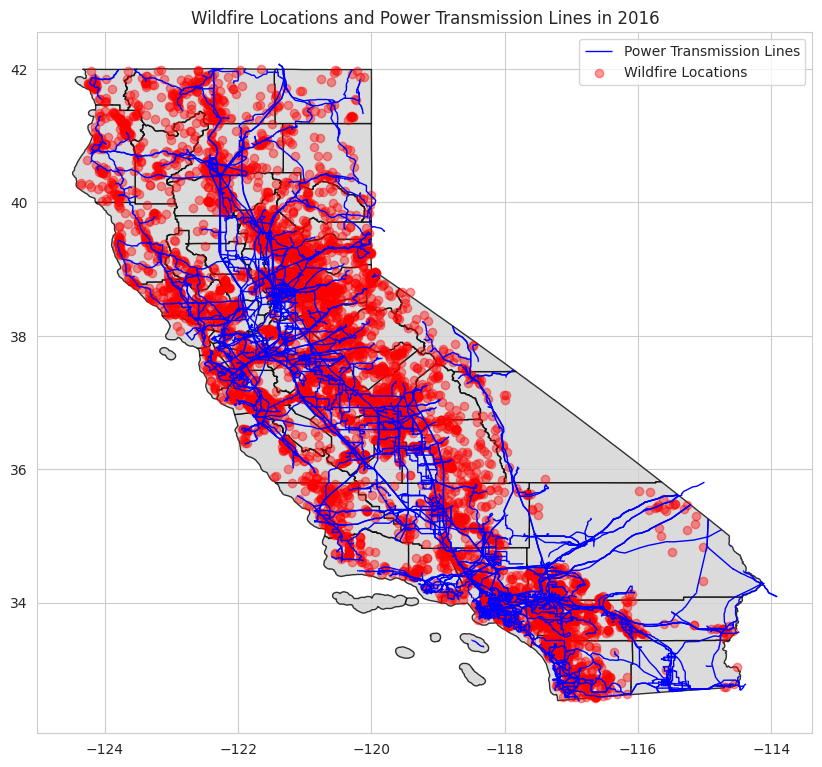

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

print(counties.columns)


min_longitude = -124.4  # Westernmost point of California
max_longitude = -114.1  # Easternmost point of California
min_latitude = 32.5    # Southernmost point of California
max_latitude = 42.0    # Northernmost point of California


# Plot wildfire locations (points
wildfire_ca_copy = wildfire_ca.copy()
wildfire_ca_copy['DISCOVERY_DATE'] = pd.to_datetime(wildfire_ca_copy['DISCOVERY_DATE'], format='%m/%d/%Y')
wildfire_ca_copy['Year'] = wildfire_ca_copy['DISCOVERY_DATE'].dt.year
wildfire_ca_copy.sort_values(by=['Year'], inplace=True)

wildfire_ca_copy = wildfire_ca_copy[wildfire_ca_copy['Year'] == filter_year]
print(wildfire_ca_copy.columns)


wildfire_ca_copy = wildfire_ca_copy[
    ~(wildfire_ca_copy['LONGITUDE'] < min_longitude) &
    ~(wildfire_ca_copy['LONGITUDE'] > max_longitude) &
    ~(wildfire_ca_copy['LATITUDE'] < min_latitude) &
    ~(wildfire_ca_copy['LATITUDE'] > max_latitude)
]

wildfire_gdf = gpd.GeoDataFrame(
    wildfire_ca_copy[['LATITUDE', 'LONGITUDE']],
    geometry=gpd.points_from_xy(wildfire_ca_copy.LONGITUDE, wildfire_ca_copy.LATITUDE),
    crs="EPSG:3857"
)
counties.to_crs(epsg=4326, inplace=True)
transmission_gdf.to_crs(epsg=4326, inplace=True)
# print(counties['geometry'])
# print(wildfire_gdf['geometry'][0], wildfire_gdf.crs)


# # Plot power transmission lines (lines)
transmission_gdf.plot(ax=ax, color='blue', linewidth=1, label="Power Transmission Lines")


counties.plot(ax=ax, color="lightgray", edgecolor="black", alpha=0.8)
# # # Add title and legend

wildfire_gdf.plot(ax=ax, color='Red', label="Wildfire Locations", alpha = 0.4)
plt.title("Wildfire Locations and Power Transmission Lines in {}".format(filter_year))
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/transmission_wildfire{}'.format(filter_year)
plt.savefig(save_path)
plt.legend()

# Show the plot
plt.show()

##Tree Coverage in California

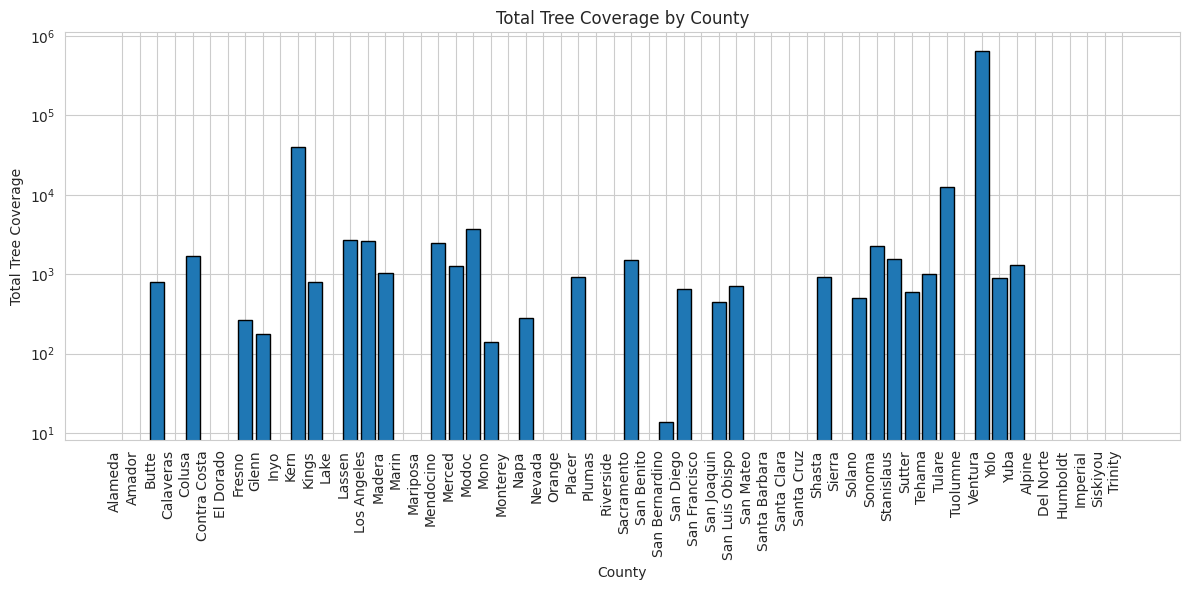

In [ ]:
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
vegetations_to_merge_ = vegetations_to_merge.copy()
vegetations_to_merge_ = vegetations_to_merge_.reset_index()
plt.yscale('log')
plt.bar(vegetations_to_merge_['County'], vegetations_to_merge_['TreeCov'], edgecolor='black')
plt.title('Total Tree Coverage by County')
plt.xlabel('County')
plt.ylabel('Total Tree Coverage')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


## Weather map


### Temperature

Index(['County', 'Time', 'Maximum Temperature (°F)',
       'Average Temperature (°F)', 'Precipitation (Inches)'],
      dtype='object')
Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')


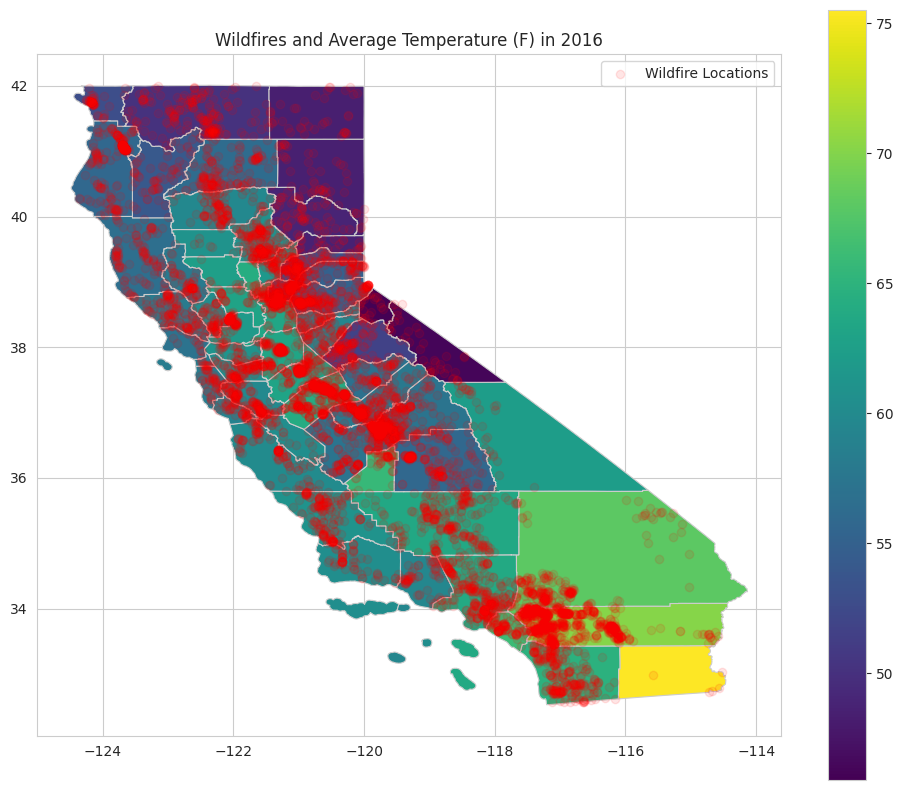

In [ ]:
import matplotlib.pyplot as plt
weather_ = df_weather.copy()

weather_  = weather_[weather_['Time'] == filter_year]
print(weather_.columns)
counties_ = counties.copy()
counties_ = counties.rename(columns={'NAME': 'County'})
counties_ = pd.merge(counties_, weather_, on='County', how='left')
print(counties.columns)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))  # Adjust figure size as needed
counties_.plot(column='Average Temperature (°F)', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

wildfire_gdf.plot(ax=ax, color='Red', label="Wildfire Locations", alpha = 0.1)
plt.title("Wildfires and Maximal Temperature (F) in {}".format(filter_year))
plt.legend()
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/Temperature_wildfire{}'.format(filter_year)
plt.savefig(save_path)

ax.set_title('Wildfires and Average Temperature (F) in {}'.format(filter_year))
plt.show()

### Precipitation

Index(['County', 'Time', 'Maximum Temperature (°F)',
       'Average Temperature (°F)', 'Precipitation (Inches)'],
      dtype='object')
Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')


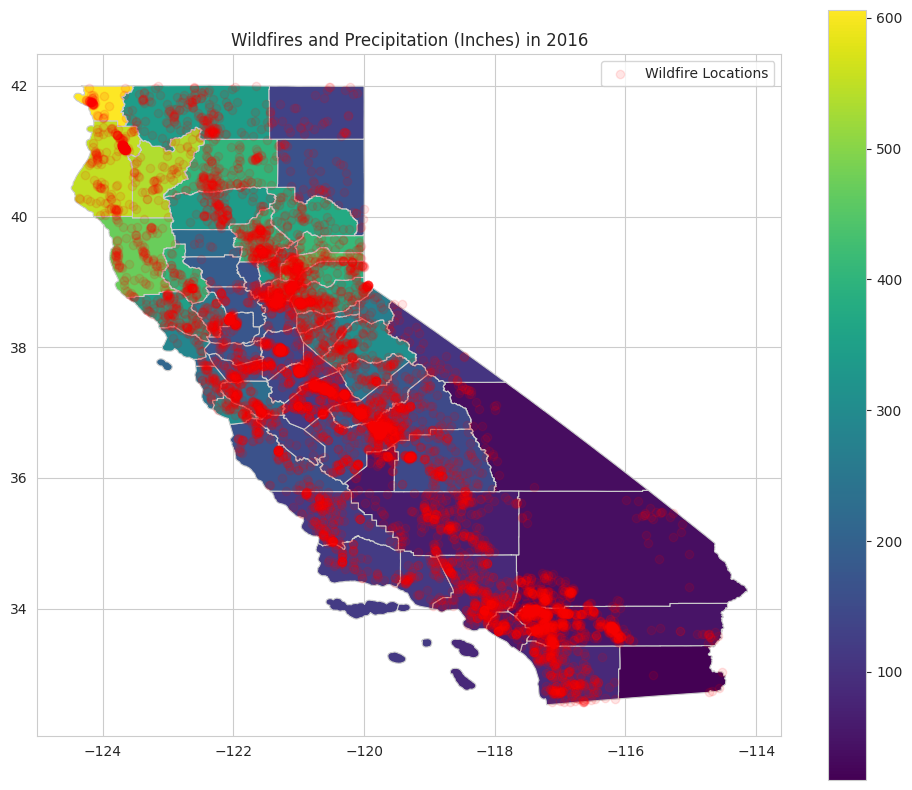

In [ ]:
import matplotlib.pyplot as plt
weather_ = df_weather.copy()
weather_  = weather_[weather_['Time'] == filter_year]
print(weather_.columns)
counties_ = counties.copy()
counties_ = counties.rename(columns={'NAME': 'County'})
counties_ = pd.merge(counties_, weather_, on='County', how='left')
print(counties.columns)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))  # Adjust figure size as needed
counties_.plot(column='Precipitation (Inches)', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

wildfire_gdf.plot(ax=ax, color='Red', label="Wildfire Locations", alpha = 0.1)
plt.title("Wildfires and Precipitation (Inches) in {}".format(filter_year))
plt.legend()
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/Precipitation_wildfire{}'.format(filter_year)
plt.savefig(save_path)

ax.set_title('Wildfires and Precipitation (Inches) in {}'.format(filter_year))
plt.show()

##Electricity Consumption

Index(['OBJECTID', 'Shape', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE',
       'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_PLUS_INCIDENT_JOIN_ID', 'ICS_209_PLUS_COMPLEX_JOIN_ID',
       'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR',
       'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'NWCG_CAUSE_CLASSIFICATION', 'NWCG_GENERAL_CAUSE',
       'NWCG_CAUSE_AGE_CATEGORY', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME',
       'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_DESCR',
       'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME', 'Year'],
      dtype='object')
Index(['County', 'Time', 'GWh'], dtype='object')


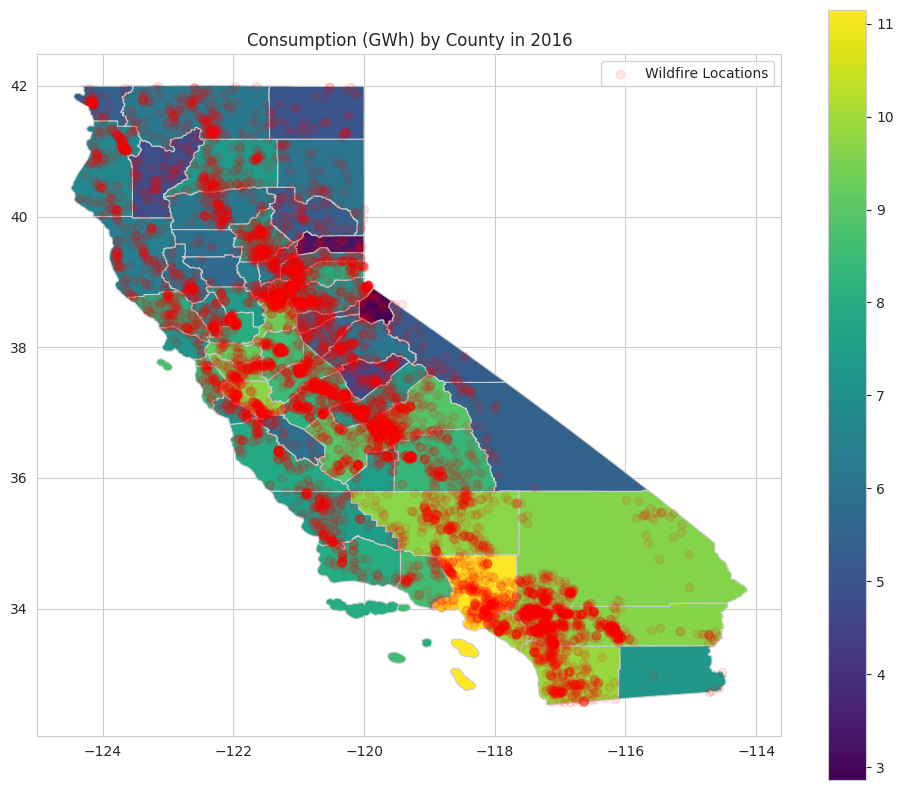

In [ ]:
import matplotlib.pyplot as plt
import math

min_longitude = -124.4  # Westernmost point of California
max_longitude = -114.1  # Easternmost point of California
min_latitude = 32.5    # Southernmost point of California
max_latitude = 42.0    # Northernmost point of California


# Plot wildfire locations (points
wildfire_ca_copy = wildfire_ca.copy()
wildfire_ca_copy['DISCOVERY_DATE'] = pd.to_datetime(wildfire_ca_copy['DISCOVERY_DATE'], format='%m/%d/%Y')
wildfire_ca_copy['Year'] = wildfire_ca_copy['DISCOVERY_DATE'].dt.year
wildfire_ca_copy.sort_values(by=['Year'], inplace=True)

wildfire_ca_copy = wildfire_ca_copy[wildfire_ca_copy['Year'] == filter_year]
print(wildfire_ca_copy.columns)


wildfire_ca_copy = wildfire_ca_copy[
    ~(wildfire_ca_copy['LONGITUDE'] < min_longitude) &
    ~(wildfire_ca_copy['LONGITUDE'] > max_longitude) &
    ~(wildfire_ca_copy['LATITUDE'] < min_latitude) &
    ~(wildfire_ca_copy['LATITUDE'] > max_latitude)
]

wildfire_gdf = gpd.GeoDataFrame(
    wildfire_ca_copy[['LATITUDE', 'LONGITUDE']],
    geometry=gpd.points_from_xy(wildfire_ca_copy.LONGITUDE, wildfire_ca_copy.LATITUDE),
    crs="EPSG:3857"
)


consumption_ = electricity_consumption_df.copy()

print(consumption_.columns)
consumption_ = consumption_[consumption_['Time'] == filter_year]
consumption_['GWh'] = consumption_['GWh'].apply(lambda x: math.log(x))
counties_ = counties.copy()
counties_ = counties.rename(columns={'NAME': 'County'})
counties_ = pd.merge(counties_, consumption_, on='County', how='left')
fig, ax = plt.subplots(1, 1, figsize=(12, 10))  # Adjust figure size as needed
counties_.plot(column='GWh', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

wildfire_gdf.plot(ax=ax, color='Red', label="Wildfire Locations", alpha = 0.1)
plt.title("Consumption (GWh) by County in {}".format(filter_year))
plt.legend()
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/Consumption_wildfire{}'.format(filter_year)
plt.savefig(save_path)

ax.set_title('Consumption (GWh) by County in {}'.format(filter_year))
plt.show()

Correlations

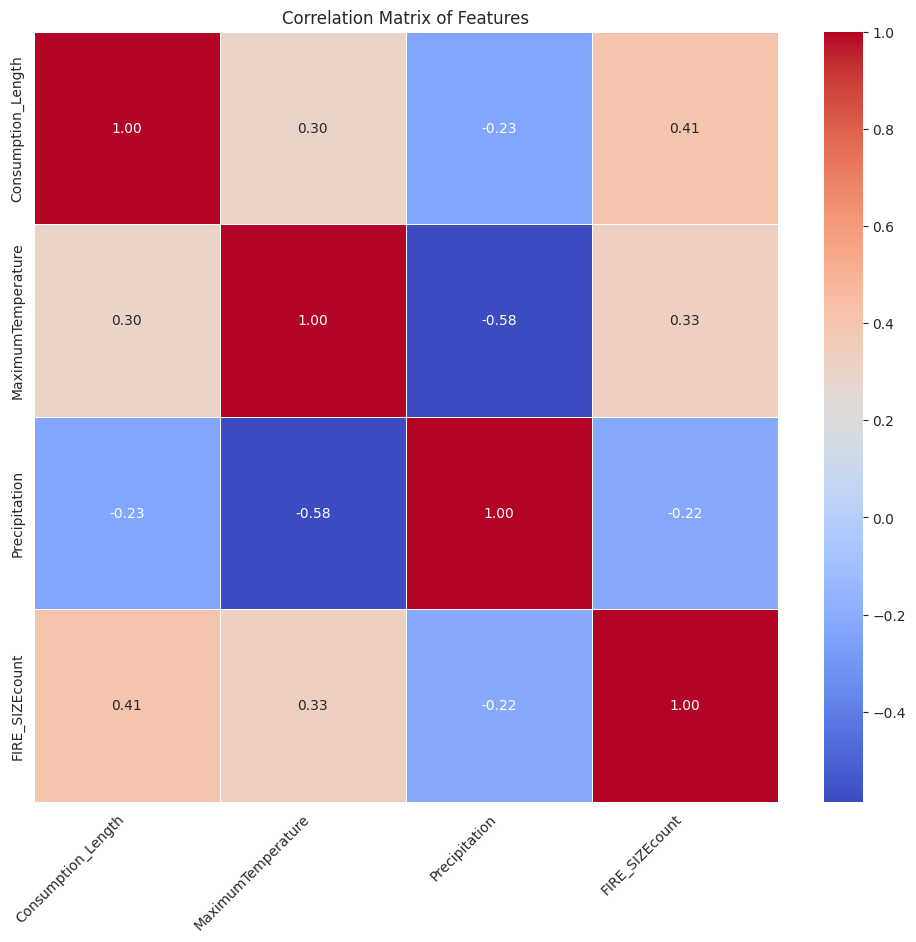

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Consumption_Length','MaximumTemperature','Precipitation']
corr_features = features + ['FIRE_SIZEcount']

corr_matrix = df[corr_features].corr()

# Increase the figure size
plt.figure(figsize=(12, 10))

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Add title
plt.title('Correlation Matrix of Features')

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45, ha='right')
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/Correlation'
plt.savefig(save_path)
# Display the plot
plt.show()

This plot shows the importance of our features compared to conentional features such as maximal temperature and recipitation.